# Libraries and EDA

## Directing to Root path

In [9]:
import os
import sys
from pathlib import Path

# 1. Get current working directory
current_dir = Path.cwd()

# 2. If we are inside one of the subfolders, step back up to the parent (PROJECT2)
if current_dir.name in ['models', 'experiments', 'data_prep']:
    os.chdir(current_dir.parent)
    
# 3. Add the root project folder to the system path ONLY if it isn't already there
project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Working directory safely set to: {Path.cwd()}")

Working directory safely set to: /Users/emaheshwari/Project2


## Import Libraries


In [10]:
import torch
import os
import ssl
import fsspec
import urllib.request
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import pandas as pd
import numpy as np


## SSL Bypass and Dataset Loading

In [11]:


# 1. Force SSL Bypass for the manual download
ssl._create_default_https_context = ssl._create_unverified_context

# 2. Define the EXACT path structure PyG expects
# Root is ./data/Cora, but PyG looks for files in ./data/Cora/Cora/raw
base_path = './data/Cora'
raw_dir = os.path.join(base_path, 'Cora', 'raw')
os.makedirs(raw_dir, exist_ok=True)

# 3. The exact files needed by the Planetoid loader
files = [
    'ind.cora.x', 'ind.cora.y', 'ind.cora.tx', 'ind.cora.ty',
    'ind.cora.allx', 'ind.cora.ally', 'ind.cora.graph', 'ind.cora.test.index'
]
base_url = "https://github.com/kimiyoung/planetoid/raw/master/data/"

print(f"Checking for files in: {raw_dir}")
for f in files:
    save_path = os.path.join(raw_dir, f)
    if not os.path.exists(save_path):
        print(f"Downloading {f}...")
        urllib.request.urlretrieve(base_url + f, save_path)
    else:
        print(f"✅ {f} already exists.")

# 4. Load the dataset (it will now see the files and skip the network)
print("\nLoading dataset into PyTorch Geometric...")
dataset = Planetoid(root=base_path, name='Cora', transform=T.NormalizeFeatures())
data = dataset[0]

# 5. Move to your Mac's MPS device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
data = data.to(device)

print(f"\n🚀 Success! Graph loaded and moved to: {data.x.device}")

Checking for files in: ./data/Cora/Cora/raw
✅ ind.cora.x already exists.
✅ ind.cora.y already exists.
✅ ind.cora.tx already exists.
✅ ind.cora.ty already exists.
✅ ind.cora.allx already exists.
✅ ind.cora.ally already exists.
✅ ind.cora.graph already exists.
✅ ind.cora.test.index already exists.

Loading dataset into PyTorch Geometric...

🚀 Success! Graph loaded and moved to: mps:0


In [12]:
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


## Label Classes to NetworkX

In [13]:
import networkx as nx
from torch_geometric.utils import to_networkx

# Convert the PyG graph to a NetworkX graph (undirected for easier visualization)
G = to_networkx(data, to_undirected=True)

# Actual academic labels for the Cora dataset
topic_map = {
    0: "Theory", 
    1: "Reinforcement_Learning", 
    2: "Genetic_Algorithms", 
    3: "Neural_Networks", 
    4: "Probabilistic_Methods", 
    5: "Case_Based", 
    6: "Rule_Learning"
}

print(f"Graph converted to NetworkX.")
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")

Graph converted to NetworkX.
Total Nodes: 2708
Total Edges: 5278


## Citation Graph Node and Depth Exploration

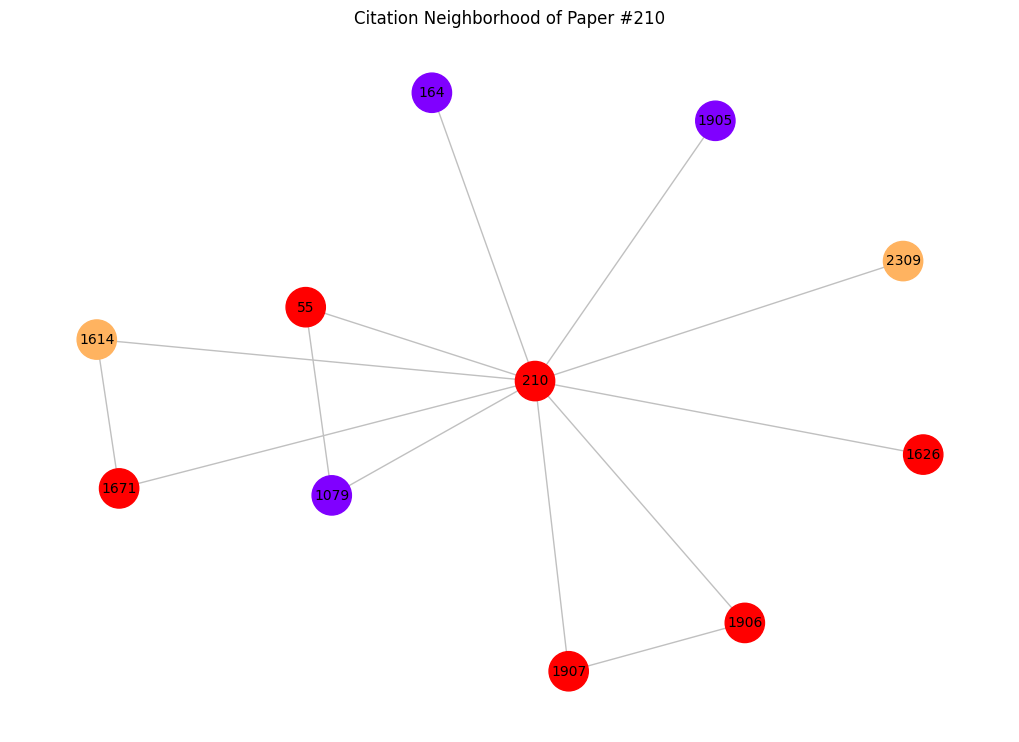

Paper #210 is connected to 10 other papers.


In [14]:
import matplotlib.pyplot as plt

# Pick a paper ID (e.g., node 100) to explore
target_node = 210

# Get the ego graph (target node + its neighbors)
ego_G = nx.ego_graph(G, target_node, radius=1)

# Get the colors (topics) for these specific nodes
node_subset = list(ego_G.nodes)
node_colors = data.y[node_subset].cpu().numpy()

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(ego_G, seed=42) # Layout for consistent positioning

# Draw the neighborhood
nx.draw(ego_G, pos, 
        node_color=node_colors, 
        with_labels=True, 
        node_size=800, 
        cmap=plt.cm.rainbow, 
        edge_color="silver",
        font_size=10)

plt.title(f"Citation Neighborhood of Paper #{target_node}")
plt.show()

print(f"Paper #{target_node} is connected to {len(list(G.neighbors(target_node)))} other papers.")

## Class Node Count Graph

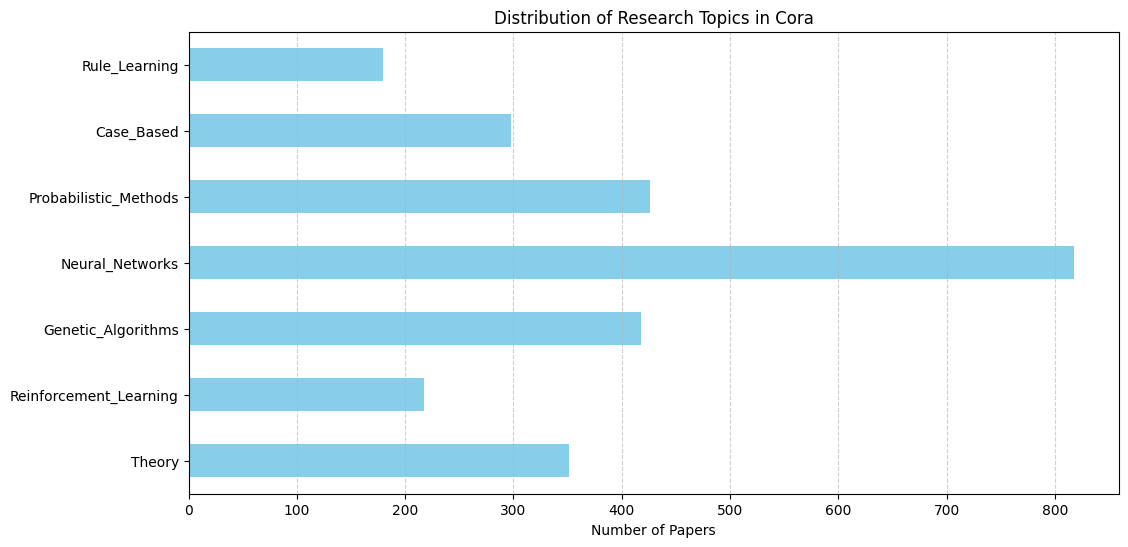

Topic Counts:
Theory                    351
Reinforcement_Learning    217
Genetic_Algorithms        418
Neural_Networks           818
Probabilistic_Methods     426
Case_Based                298
Rule_Learning             180
Name: count, dtype: int64


In [15]:
import pandas as pd

# Extract labels and map them to names
labels = data.y.cpu().numpy()
counts = pd.Series(labels).value_counts().sort_index()
counts.index = [topic_map[i] for i in counts.index]

# Plot the distribution
plt.figure(figsize=(12, 6))
counts.plot(kind='barh', color='skyblue')
plt.title("Distribution of Research Topics in Cora")
plt.xlabel("Number of Papers")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("Topic Counts:")
print(counts)

## Average, Min, and Max Citation Graph

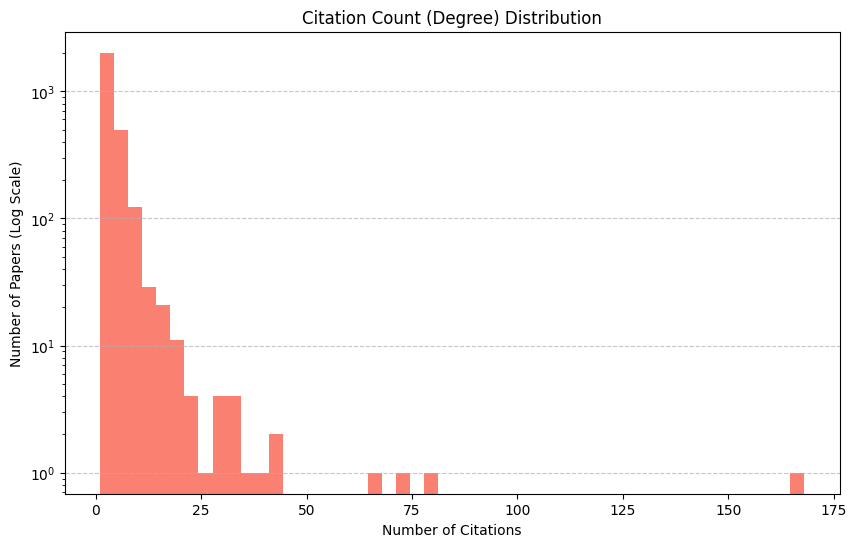

Maximum Citations for one paper: 168
Minimum Citations: 1
Average Citations per paper: 3.90
Paper #1358 is the biggest hub with 168 connections.


In [16]:
import numpy as np

# Calculate the degree of every node
degrees = [G.degree(n) for n in G.nodes()]

# Plotting the distribution
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50, color='salmon', log=True) # Using log scale because counts vary wildly
plt.title("Citation Count (Degree) Distribution")
plt.xlabel("Number of Citations")
plt.ylabel("Number of Papers (Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Maximum Citations for one paper: {max(degrees)}")
print(f"Minimum Citations: {min(degrees)}")
print(f"Average Citations per paper: {np.mean(degrees):.2f}")

# Find the hub
hub_node = max(dict(G.degree()).items(), key=lambda x: x[1])
print(f"Paper #{hub_node[0]} is the biggest hub with {hub_node[1]} connections.")